In [199]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [28]:
pd.set_option('display.max_rows', 300)

## Carregamento e filtro das categorias

In [5]:
df = pd.read_csv('./store-sales-favorita/train.csv', parse_dates=['date'])
df = df[df.date.between('2017-01-01', '2017-12-31')][['date', 'family', 'sales']]

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 404514 entries, 2596374 to 3000887
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    404514 non-null  datetime64[ns]
 1   family  404514 non-null  object        
 2   sales   404514 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 12.3+ MB


In [10]:
# Contando a quantidade de zeros por categoria
df.groupby('family')['sales'].apply(lambda x: (x == 0).sum())


family
AUTOMOTIVE                      506
BABY CARE                     10589
BEAUTY                         1776
BEVERAGES                       161
BOOKS                         10872
BREAD/BAKERY                    161
CELEBRATION                     416
CLEANING                        161
DAIRY                           161
DELI                            161
EGGS                            161
FROZEN FOODS                    161
GROCERY I                       161
GROCERY II                      655
HARDWARE                       4856
HOME AND KITCHEN I              170
HOME AND KITCHEN II             177
HOME APPLIANCES                8144
HOME CARE                       163
LADIESWEAR                     3817
LAWN AND GARDEN                3872
LINGERIE                       1298
LIQUOR,WINE,BEER                383
MAGAZINES                      1958
MEATS                           161
PERSONAL CARE                   161
PET SUPPLIES                   1526
PLAYERS AND ELECTRONI

In [11]:
df = df[df.family.isin(['AUTOMOTIVE', 'BEVERAGES', 'EGGS'])]
df.groupby('family').agg({'sales': 'sum'})

,sales
family,
AUTOMOTIVE,91024.0
BEVERAGES,43952592.0
EGGS,2416757.0


In [18]:
df = df[['date', 'family', 'sales']].set_index('date')

## Série não estacionária

        Data      Valor
0 2023-01-01   0.993428
1 2023-01-02   2.913641
2 2023-01-03   7.373230
3 2023-01-04  11.436230
4 2023-01-05   9.442258


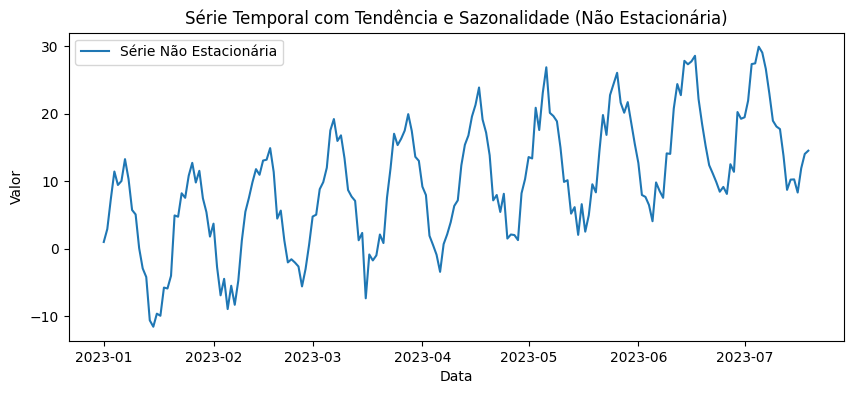

In [184]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define tamanho da série
n = 200
np.random.seed(42)

# Cria uma tendência linear e um componente aleatório
t = np.arange(n)
trend = 0.1 * t                     # tendência crescente
seasonal = 10 * np.sin(2 * np.pi * t / 20)  # componente sazonal
noise = np.random.normal(0, 2, n)   # ruído branco

# Combina tudo
serie = trend + seasonal + noise

# Coloca em um DataFrame com datas são 200 dias
datas = pd.date_range(start='2023-01-01', periods=n, freq='D')
df = pd.DataFrame({'Data': datas, 'Valor': serie})
df_trend = pd.DataFrame({'Data': datas, 'Valor': trend})
df_seasonal = pd.DataFrame({'Data': datas, 'Valor': seasonal})
df_noise = pd.DataFrame({'Data': datas, 'Valor': noise})

# Exibe e plota
print(df.head())
plt.figure(figsize=(10,4))
plt.plot(df['Data'], df['Valor'], label='Série Não Estacionária')
plt.title('Série Temporal com Tendência e Sazonalidade (Não Estacionária)')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

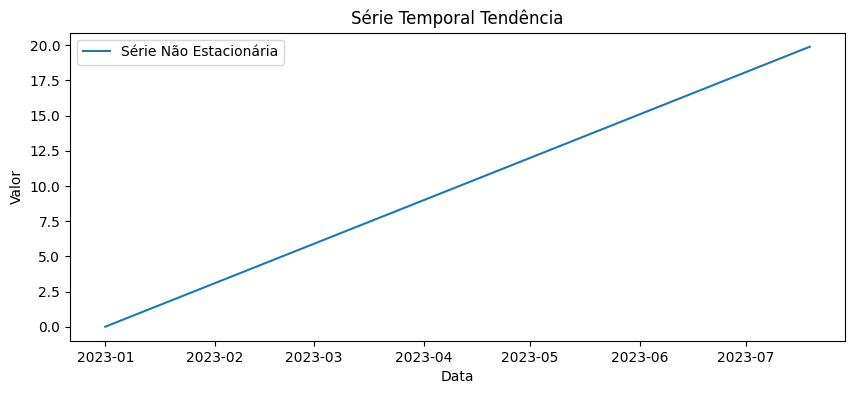

In [185]:
plt.figure(figsize=(10,4))
plt.plot(df_trend['Data'], df_trend['Valor'], label='Série Não Estacionária')
plt.title('Série Temporal Tendência')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

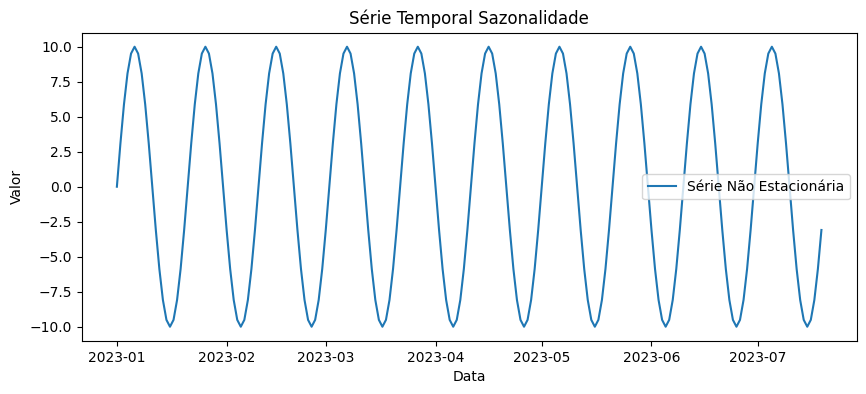

In [186]:
plt.figure(figsize=(10,4))
plt.plot(df_seasonal['Data'], df_seasonal['Valor'], label='Série Não Estacionária')
plt.title('Série Temporal Sazonalidade')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

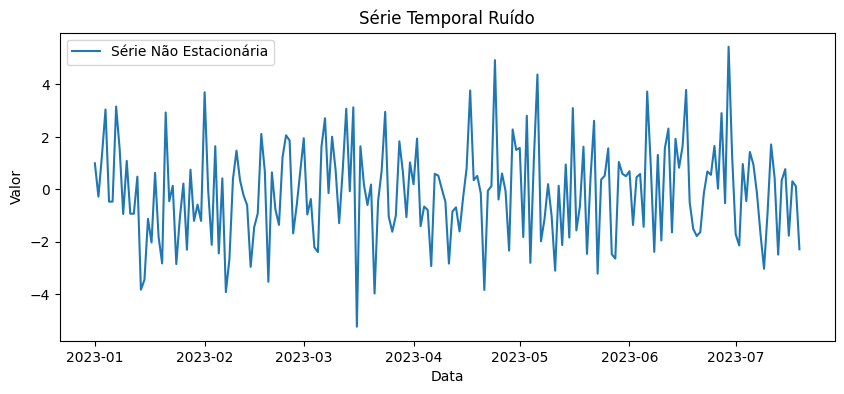

In [187]:
plt.figure(figsize=(10,4))
plt.plot(df_noise['Data'], df_noise['Valor'], label='Série Não Estacionária')
plt.title('Série Temporal Ruído')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

## Testando estacionaridade

In [119]:
from statsmodels.tsa.stattools import adfuller, kpss

In [120]:
res_ad = adfuller(df[['Valor']])
res_kp = kpss(df[['Valor']]) # kpss sempre apresentando warning, olhar isso com outro conjunto de dados

In [121]:
# p-value < 0.05 portanto hipótese nula rejeitada, série estacionária
res_ad

(np.float64(-0.7301109301072168),
 np.float64(0.8387952213851444),
 15,
 184,
 {'1%': np.float64(-3.466398230774071),
  '5%': np.float64(-2.8773796387256514),
  '10%': np.float64(-2.575213838610586)},
 np.float64(820.3990601167642))

In [122]:
res_kp

(np.float64(1.1766480346462718),
 np.float64(0.01),
 9,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [123]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

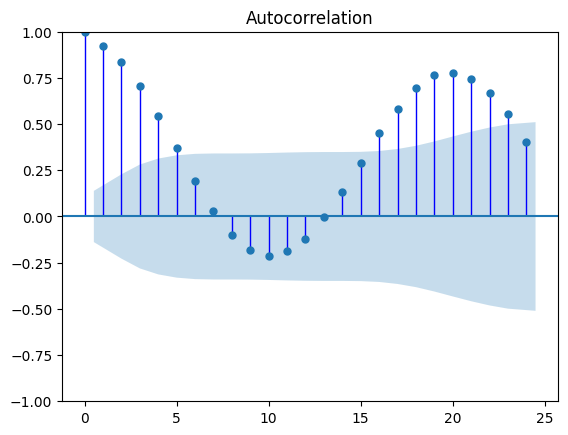

In [124]:
plot_acf(df[['Valor']], alpha=.05, vlines_kwargs={'colors': 'blue', 'linewidth': 1});

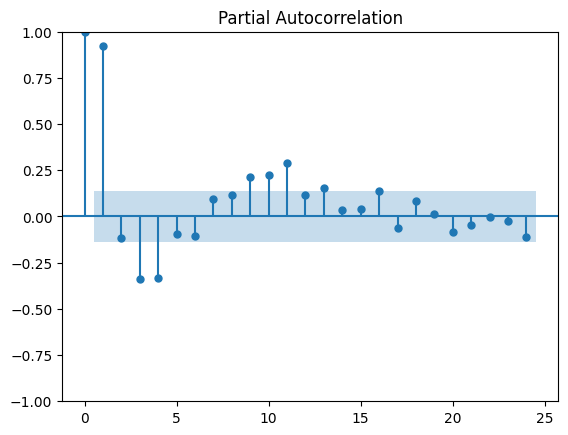

In [54]:
plot_pacf(df[['Valor']]);

## Alguns ajustes que podem ser feitos na base para deixá-la estacionária

https://medium.com/code-applied/time-series-analysis-and-forecasting-a-comparison-of-stationary-and-non-stationary-time-series-7067c0dc7e08

### Diff

In [125]:

df['diff_Valor'] = df['Valor'].diff().fillna(0)
df.head(15)

,Data,Valor,diff_Valor
0,2023-01-01,0.993428,0.000000
1,2023-01-02,2.913641,1.920213
2,2023-01-03,7.373230,4.459588
3,2023-01-04,11.436230,4.063000
4,2023-01-05,9.442258,-1.993971
5,2023-01-06,10.031726,0.589468
6,2023-01-07,13.268991,3.237265
7,2023-01-08,10.325039,-2.943951
8,2023-01-09,5.738904,-4.586136
9,2023-01-10,5.075290,-0.663614


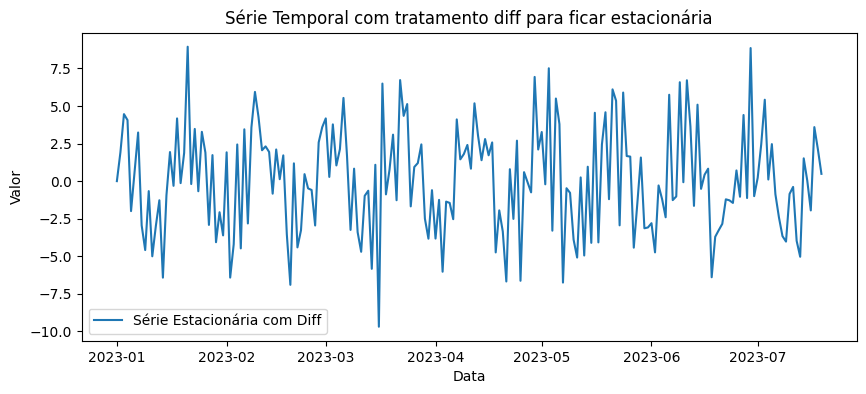

In [126]:
plt.figure(figsize=(10,4))
plt.plot(df['Data'], df['diff_Valor'], label='Série Estacionária com Diff')
plt.title('Série Temporal com tratamento diff para ficar estacionária')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [127]:
def stat_test(df, column):
    print(f"ADFULLER: {adfuller(df[[column]])}")
    print(f"KPSS: {kpss(df[[column]])}")

stat_test(df, 'diff_Valor')

ADFULLER: (np.float64(-9.505643216747002), np.float64(3.353122323117064e-16), 15, 184, {'1%': np.float64(-3.466398230774071), '5%': np.float64(-2.8773796387256514), '10%': np.float64(-2.575213838610586)}, np.float64(818.214358081409))
KPSS: (np.float64(0.013192767999009867), np.float64(0.1), 7, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})


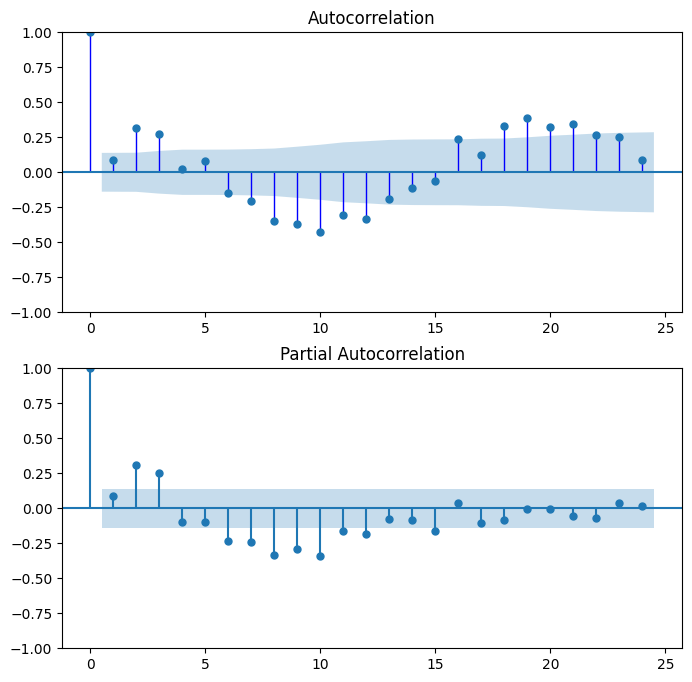

In [128]:
_, ax = plt.subplots(2, 1, figsize=(8, 8))
plot_acf(df[['diff_Valor']], alpha=.05, vlines_kwargs={'colors': 'blue', 'linewidth': 1}, ax=ax[0])
plot_pacf(df[['diff_Valor']], ax=ax[1]);

### Log

In [129]:
# Para log todos os valores devem ser positivos
df['log_Valor'] = np.log(np.abs(df['Valor'])).fillna(0)
df.head(15)

,Data,Valor,diff_Valor,log_Valor
0,2023-01-01,0.993428,0.000000,-0.006593
1,2023-01-02,2.913641,1.920213,1.069404
2,2023-01-03,7.373230,4.459588,1.997856
3,2023-01-04,11.436230,4.063000,2.436786
4,2023-01-05,9.442258,-1.993971,2.245195
5,2023-01-06,10.031726,0.589468,2.305753
6,2023-01-07,13.268991,3.237265,2.585430
7,2023-01-08,10.325039,-2.943951,2.334572
8,2023-01-09,5.738904,-4.586136,1.747268
9,2023-01-10,5.075290,-0.663614,1.624384


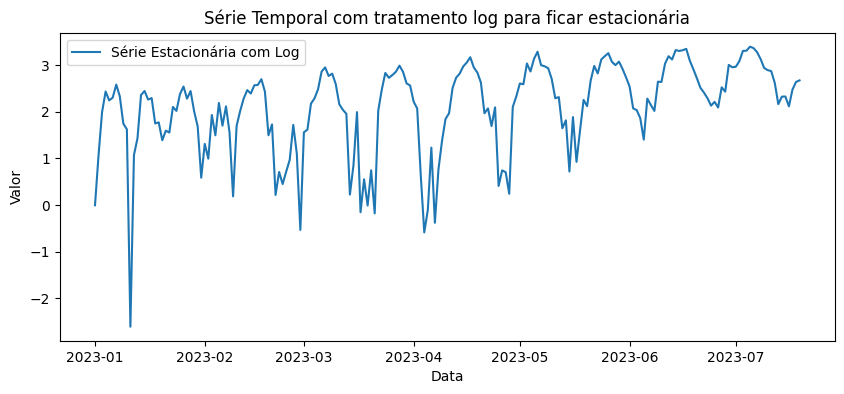

In [130]:
plt.figure(figsize=(10,4))
plt.plot(df['Data'], df['log_Valor'], label='Série Estacionária com Log')
plt.title('Série Temporal com tratamento log para ficar estacionária')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [131]:
stat_test(df, 'log_Valor')

ADFULLER: (np.float64(-5.1827506149794855), np.float64(9.53371720503937e-06), 4, 195, {'1%': np.float64(-3.464337030867007), '5%': np.float64(-2.876478799035722), '10%': np.float64(-2.574733103221565)}, np.float64(302.04485062498816))
KPSS: (np.float64(0.9607107953520188), np.float64(0.01), 8, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})


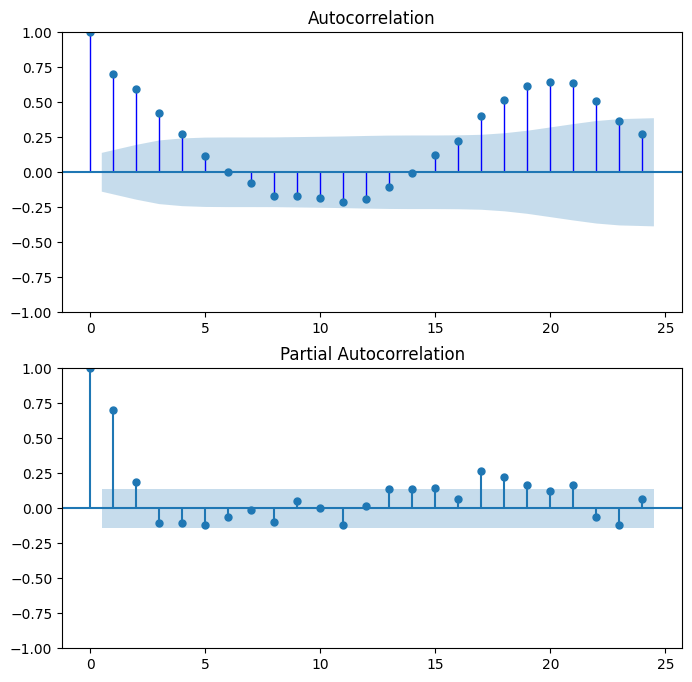

In [132]:
_, ax = plt.subplots(2, 1, figsize=(8, 8))
plot_acf(df[['log_Valor']], alpha=.05, vlines_kwargs={'colors': 'blue', 'linewidth': 1}, ax=ax[0])
plot_pacf(df[['log_Valor']], ax=ax[1]);

### BoxCox

In [133]:
# Box-Cox exige todos os números positivos
from sklearn.preprocessing import PowerTransformer as pt
from scipy.stats import boxcox
df['boxcox_Valor'], _ = boxcox(np.abs(df['Valor']))
df['skl_boxcox_Valor'] = pt(method='box-cox').fit_transform(np.abs(df[['Valor']]))
df.head(15)

,Data,Valor,diff_Valor,log_Valor,boxcox_Valor,skl_boxcox_Valor
0,2023-01-01,0.993428,0.000000,-0.006593,-0.006582,-1.809985
1,2023-01-02,2.913641,1.920213,1.069404,1.420215,-1.214803
2,2023-01-03,7.373230,4.459588,1.997856,3.461524,-0.363280
3,2023-01-04,11.436230,4.063000,2.436786,4.817248,0.202254
4,2023-01-05,9.442258,-1.993971,2.245195,4.188190,-0.060155
5,2023-01-06,10.031726,0.589468,2.305753,4.380448,0.020045
6,2023-01-07,13.268991,3.237265,2.585430,5.349234,0.424170
7,2023-01-08,10.325039,-2.943951,2.334572,4.474040,0.059086
8,2023-01-09,5.738904,-4.586136,1.747268,2.812715,-0.633928
9,2023-01-10,5.075290,-0.663614,1.624384,2.523474,-0.754584


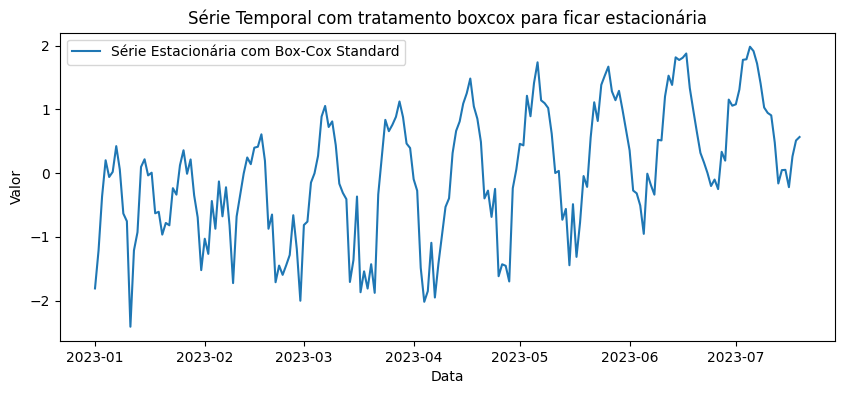

In [135]:
plt.figure(figsize=(10,4))
plt.plot(df['Data'], df['skl_boxcox_Valor'], label='Série Estacionária com Box-Cox Standard')
plt.title('Série Temporal com tratamento boxcox para ficar estacionária')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

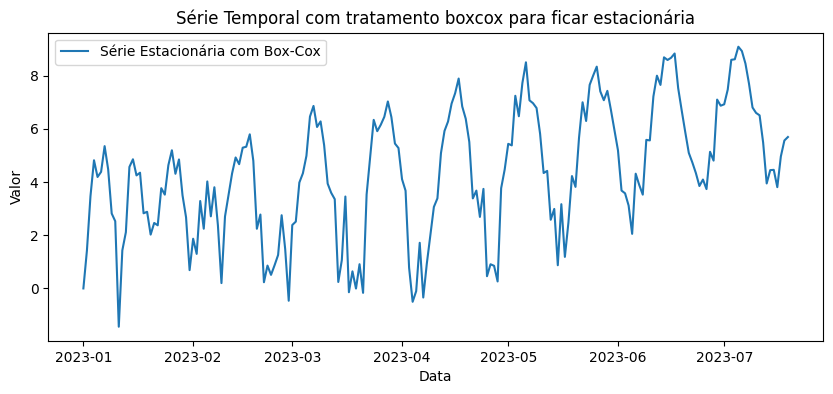

In [136]:
plt.figure(figsize=(10,4))
plt.plot(df['Data'], df['boxcox_Valor'], label='Série Estacionária com Box-Cox')
plt.title('Série Temporal com tratamento boxcox para ficar estacionária')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [139]:
# Com box-cox a série não virou estacionária
stat_test(df, 'skl_boxcox_Valor')
print()
stat_test(df, 'boxcox_Valor')

ADFULLER: (np.float64(-0.8522008578544666), np.float64(0.8033057689888589), 15, 184, {'1%': np.float64(-3.466398230774071), '5%': np.float64(-2.8773796387256514), '10%': np.float64(-2.575213838610586)}, np.float64(225.5291346721699))
KPSS: (np.float64(1.0208801773204004), np.float64(0.01), 8, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

ADFULLER: (np.float64(-0.8522008578544683), np.float64(0.8033057689888583), 15, 184, {'1%': np.float64(-3.466398230774071), '5%': np.float64(-2.8773796387256514), '10%': np.float64(-2.575213838610586)}, np.float64(547.2789676096218))
KPSS: (np.float64(1.0208801773203997), np.float64(0.01), 8, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})


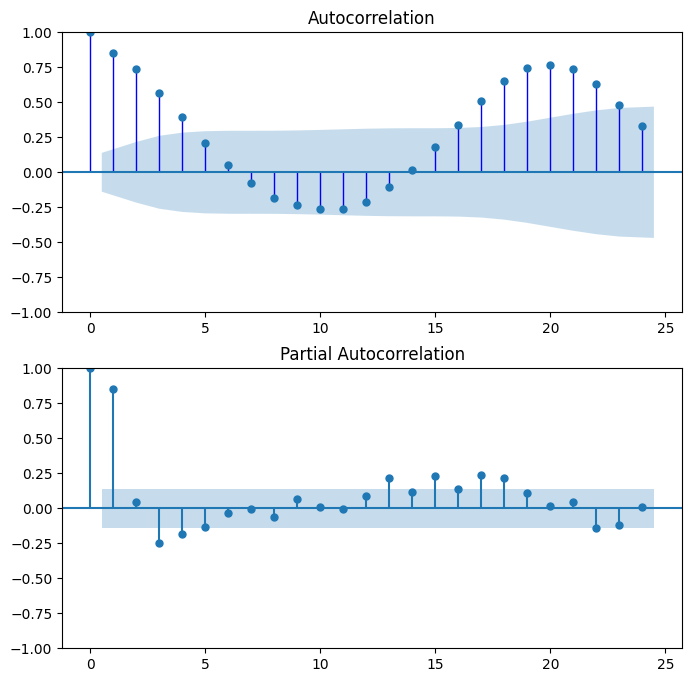

In [102]:
_, ax = plt.subplots(2, 1, figsize=(8, 8))
plot_acf(df[['boxcox_Valor']], alpha=.05, vlines_kwargs={'colors': 'blue', 'linewidth': 1}, ax=ax[0])
plot_pacf(df[['boxcox_Valor']], ax=ax[1]);

### Yeo-Jhonson

In [140]:
from scipy.stats import yeojohnson
df['yeo_Valor'], _ = yeojohnson(df['Valor'])
df['skl_yeo_Valor'] = pt(method='yeo-johnson').fit_transform(df[['Valor']])
df.head(15)

,Data,Valor,diff_Valor,log_Valor,boxcox_Valor,skl_boxcox_Valor,yeo_Valor,skl_yeo_Valor
0,2023-01-01,0.993428,0.000000,-0.006593,-0.006582,-1.809985,0.990238,-0.965974
1,2023-01-02,2.913641,1.920213,1.069404,1.420215,-1.214803,2.893410,-0.754611
2,2023-01-03,7.373230,4.459588,1.997856,3.461524,-0.363280,7.286571,-0.266715
3,2023-01-04,11.436230,4.063000,2.436786,4.817248,0.202254,11.270880,0.175776
4,2023-01-05,9.442258,-1.993971,2.245195,4.188190,-0.060155,9.317164,-0.041201
5,2023-01-06,10.031726,0.589468,2.305753,4.380448,0.020045,9.895032,0.022976
6,2023-01-07,13.268991,3.237265,2.585430,5.349234,0.424170,13.064309,0.374951
7,2023-01-08,10.325039,-2.943951,2.334572,4.474040,0.059086,10.182476,0.054899
8,2023-01-09,5.738904,-4.586136,1.747268,2.812715,-0.633928,5.679661,-0.445175
9,2023-01-10,5.075290,-0.663614,1.624384,2.523474,-0.754584,5.026286,-0.517738


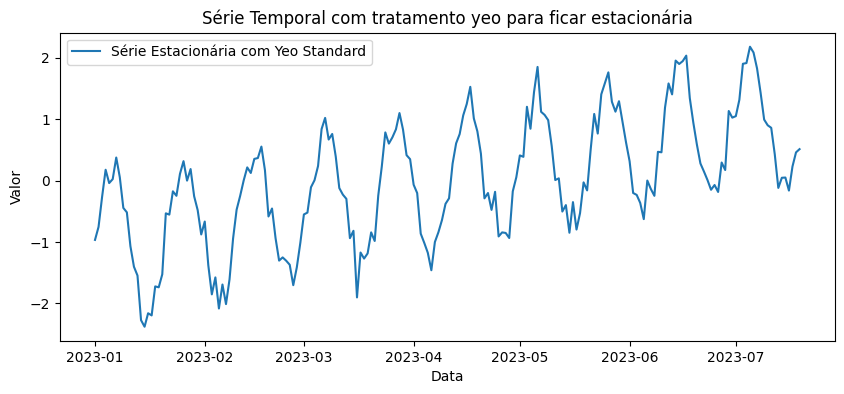

In [141]:
plt.figure(figsize=(10,4))
plt.plot(df['Data'], df['skl_yeo_Valor'], label='Série Estacionária com Yeo Standard')
plt.title('Série Temporal com tratamento yeo para ficar estacionária')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

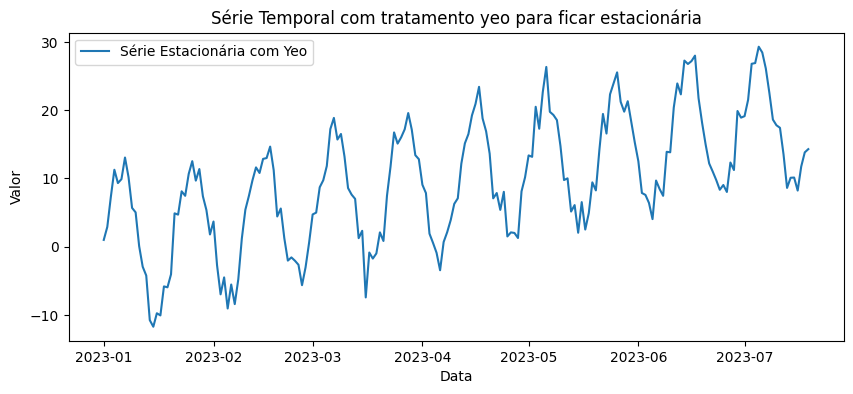

In [142]:
plt.figure(figsize=(10,4))
plt.plot(df['Data'], df['yeo_Valor'], label='Série Estacionária com Yeo')
plt.title('Série Temporal com tratamento yeo para ficar estacionária')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [144]:
# Yeo também não foi capaz de deixar a série estacionária
stat_test(df, 'skl_yeo_Valor')
print()
stat_test(df, 'yeo_Valor')

ADFULLER: (np.float64(-0.7737093131789236), np.float64(0.8267230502420251), 15, 184, {'1%': np.float64(-3.466398230774071), '5%': np.float64(-2.8773796387256514), '10%': np.float64(-2.575213838610586)}, np.float64(6.883562344203767))
KPSS: (np.float64(1.176839213177776), np.float64(0.01), 9, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

ADFULLER: (np.float64(-0.7737093381335228), np.float64(0.8267230431425617), 15, 184, {'1%': np.float64(-3.466398230774071), '5%': np.float64(-2.8773796387256514), '10%': np.float64(-2.575213838610586)}, np.float64(815.6375139207255))
KPSS: (np.float64(1.1768392132656007), np.float64(0.01), 9, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})


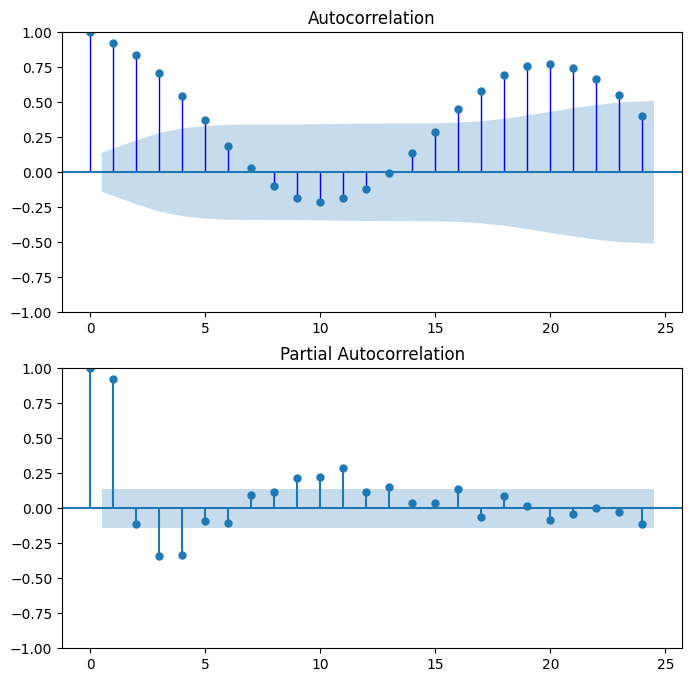

In [145]:
_, ax = plt.subplots(2, 1, figsize=(8, 8))
plot_acf(df[['yeo_Valor']], alpha=.05, vlines_kwargs={'colors': 'blue', 'linewidth': 1}, ax=ax[0])
plot_pacf(df[['yeo_Valor']], ax=ax[1]);

### Testando transformações do box-cox e yeo-johnson

In [149]:
dft = df[['Data', 'Valor']]
dft['scp_box'], _ = boxcox(np.abs(df['Valor']))
dft['skl_box'] = pt(method='box-cox', standardize=False).fit_transform(np.abs(df[['Valor']]))
dft['skl_std_box'] = pt(method='box-cox', standardize=True).fit_transform(np.abs(df[['Valor']]))
dft['scp_yeo'], _ = yeojohnson(df['Valor'])
dft['skl_yeo'] = pt(method='yeo-johnson', standardize=False).fit_transform(df[['Valor']])
dft['skl_std_yeo'] = pt(method='yeo-johnson', standardize=True).fit_transform(df[['Valor']])
dft.head(15)

,Data,Valor,scp_box,skl_box,skl_std_box,scp_yeo,skl_yeo,skl_std_yeo
0,2023-01-01,0.993428,-0.006582,-0.006582,-1.809985,0.990238,0.990238,-0.965974
1,2023-01-02,2.913641,1.420215,1.420215,-1.214803,2.893410,2.893410,-0.754611
2,2023-01-03,7.373230,3.461524,3.461524,-0.363280,7.286571,7.286572,-0.266715
3,2023-01-04,11.436230,4.817248,4.817248,0.202254,11.270880,11.270880,0.175776
4,2023-01-05,9.442258,4.188190,4.188190,-0.060155,9.317164,9.317164,-0.041201
5,2023-01-06,10.031726,4.380448,4.380448,0.020045,9.895032,9.895032,0.022976
6,2023-01-07,13.268991,5.349234,5.349234,0.424170,13.064309,13.064309,0.374951
7,2023-01-08,10.325039,4.474040,4.474040,0.059086,10.182476,10.182477,0.054899
8,2023-01-09,5.738904,2.812715,2.812715,-0.633928,5.679661,5.679661,-0.445175
9,2023-01-10,5.075290,2.523474,2.523474,-0.754584,5.026286,5.026286,-0.517738


### Decomposição

In [158]:
def determinar_periodo(serie_original, max_periodo=12, periodo=None):
    """
    Determina automaticamente o período sazonal
    """
    if periodo is not None:
        return periodo
        
    n = len(serie_original)
    # Usa autocorrelação para determinar período
    from statsmodels.tsa.stattools import acf
    
    autocorr = acf(serie_original, nlags=min(max_periodo, n//2))
    print(autocorr)
    # Encontra o primeiro pico significativo após o lag 0
    picos = []
    for i in range(2, len(autocorr)-1):
        if autocorr[i] > autocorr[i-1] and autocorr[i] > autocorr[i+1] and autocorr[i] > 0.1:
            picos.append(i)
    
    if picos:
        periodo = picos[0]
        print(f"Período sazonal detectado: {periodo}")
    else:
        periodo = 12  # padrão para dados mensais
        print(f"Período não detectado, usando padrão: {periodo}")
        
    return periodo

periodo = determinar_periodo(df[['Valor']])

[ 1.          0.92444329  0.83762387  0.70815294  0.5426368   0.37186169
  0.19001831  0.03216404 -0.09902743 -0.18357467 -0.21507941 -0.18767998
 -0.11928887]
Período não detectado, usando padrão: 12


In [165]:
from statsmodels.tsa.seasonal import seasonal_decompose

def decompor_serie(serie_original, modelo='additive'):
    """
    Decompõe a série em tendência, sazonalidade e resíduo
    """
    # Determina período se não fornecido
    periodo = 12
    
    # Garante que a série tem comprimento suficiente
    n = len(serie_original)
    if n < 2 * periodo:
        print(f"Aviso: Série muito curta para período {periodo}. Reduzindo período.")
        periodo = max(2, n // 2)
    
    
    # Cria índice temporal para statsmodels
    if isinstance(serie_original, pd.Series):
        serie_temp = serie_original
    else:
        serie_temp = pd.Series(serie_original)
    
    # Decomposição
    decomposicao = seasonal_decompose(serie_temp, model=modelo, period=periodo)
    
    tendencia = decomposicao.trend
    sazonalidade = decomposicao.seasonal
    residuo = decomposicao.resid
    
    print("✅ Decomposição realizada com sucesso!")
    
    return tendencia, sazonalidade, residuo
    
decomp = decompor_serie(df['Valor'])

✅ Decomposição realizada com sucesso!


In [ ]:
def tornar_estacionaria(serie_original, decomp, metodo='residual'):
    """
    Torna a série estacionária usando diferentes métodos
    
    Args:
        metodo: str, método para estacionarização
        'residual' - usa apenas o resíduo
        'deseasonalized' - remove sazonalidade
        'detrended' - remove tendência
    """
    if metodo == 'residual':
        # self.serie_estacionaria = self.residuo
        serie_estacionaria = decomp[2]
        print("Método: Resíduo da decomposição")
        
    elif metodo == 'deseasonalized':
        # self.serie_estacionaria = self.serie_original - self.sazonalidade
        serie_estacionaria = serie_original - decomp[1]
        print("Método: Série dessazonalizada")
        
    elif metodo == 'detrended':
        # self.serie_estacionaria = self.serie_original - self.tendencia
        serie_estacionaria = serie_original - decomp[0]
        print("Método: Série sem tendência")
    
    return serie_estacionaria

df['decomp_residuo'] = tornar_estacionaria(df['Valor'], decomp, metodo='residual').fillna(0)
df['decomp_sazonalidade'] = tornar_estacionaria(df['Valor'], decomp, metodo='deseasonalized').fillna(0)
df['decomp_tendencia'] = tornar_estacionaria(df['Valor'], decomp, metodo='detrended').fillna(0)

Método: Resíduo da decomposição
Método: Série dessazonalizada
Método: Série sem tendência


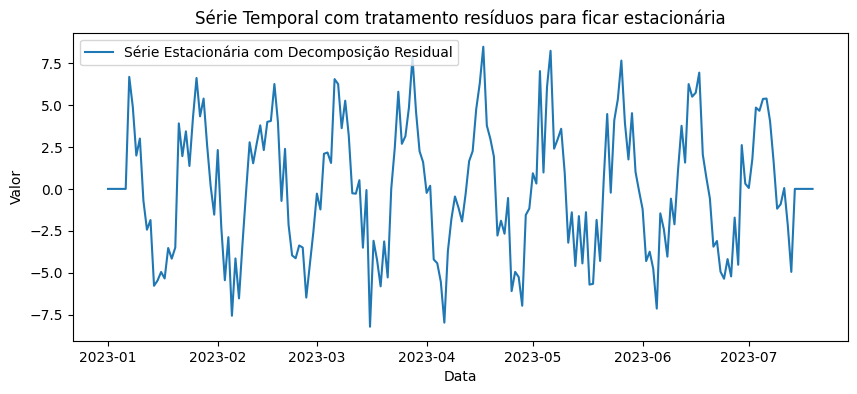

In [174]:
plt.figure(figsize=(10,4))
plt.plot(df['Data'], df['decomp_residuo'], label='Série Estacionária com Decomposição Residual')
plt.title('Série Temporal com tratamento resíduos para ficar estacionária')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [ ]:
stat_test(df, 'decomp_residuo')

ADFULLER: (np.float64(-8.357135591502864), np.float64(2.888778899326741e-13), 13, 186, {'1%': np.float64(-3.466005071659723), '5%': np.float64(-2.8772078537639385), '10%': np.float64(-2.5751221620996647)}, np.float64(768.2005556249242))
KPSS: (np.float64(0.013241128556269752), np.float64(0.1), 8, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})


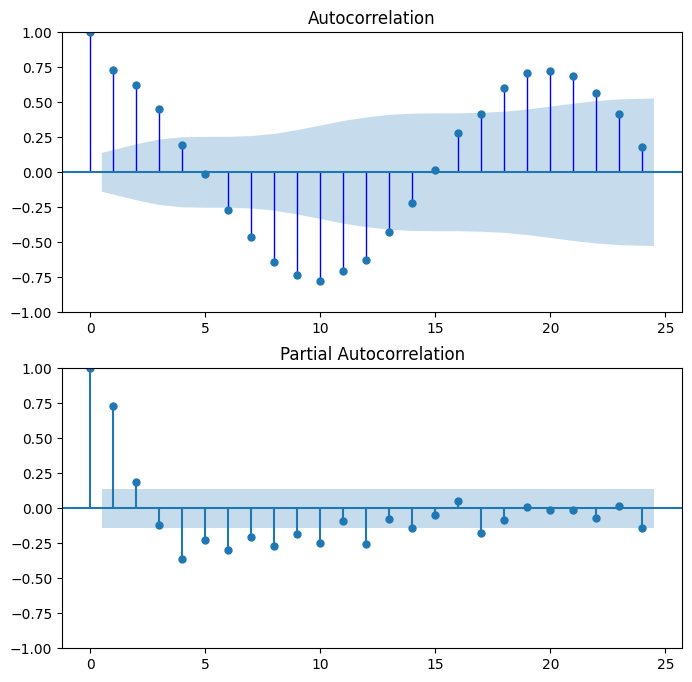

In [176]:
_, ax = plt.subplots(2, 1, figsize=(8, 8))
plot_acf(df[['decomp_residuo']], alpha=.05, vlines_kwargs={'colors': 'blue', 'linewidth': 1}, ax=ax[0])
plot_pacf(df[['decomp_residuo']], ax=ax[1]);

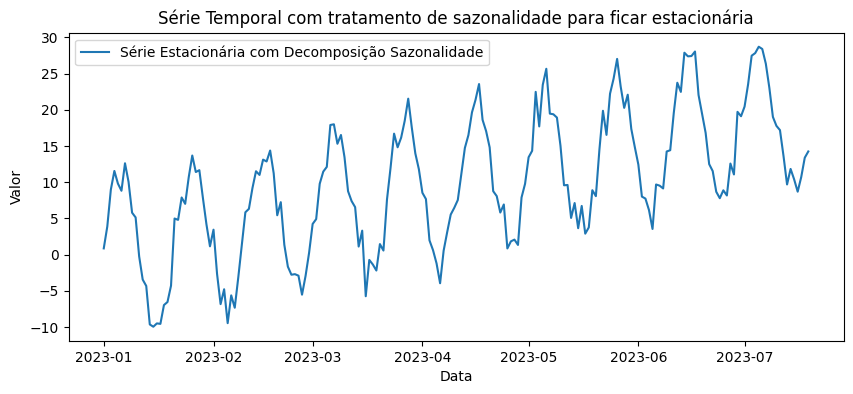

In [178]:
plt.figure(figsize=(10,4))
plt.plot(df['Data'], df['decomp_sazonalidade'], label='Série Estacionária com Decomposição Sazonalidade')
plt.title('Série Temporal com tratamento de sazonalidade para ficar estacionária')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [ ]:
# Sazonalidade não deixou a série estacionária
stat_test(df, 'decomp_sazonalidade')

ADFULLER: (np.float64(-0.6635484610154403), np.float64(0.8559667756445004), 15, 184, {'1%': np.float64(-3.466398230774071), '5%': np.float64(-2.8773796387256514), '10%': np.float64(-2.575213838610586)}, np.float64(793.813191535334))
KPSS: (np.float64(1.1726819214795658), np.float64(0.01), 9, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})


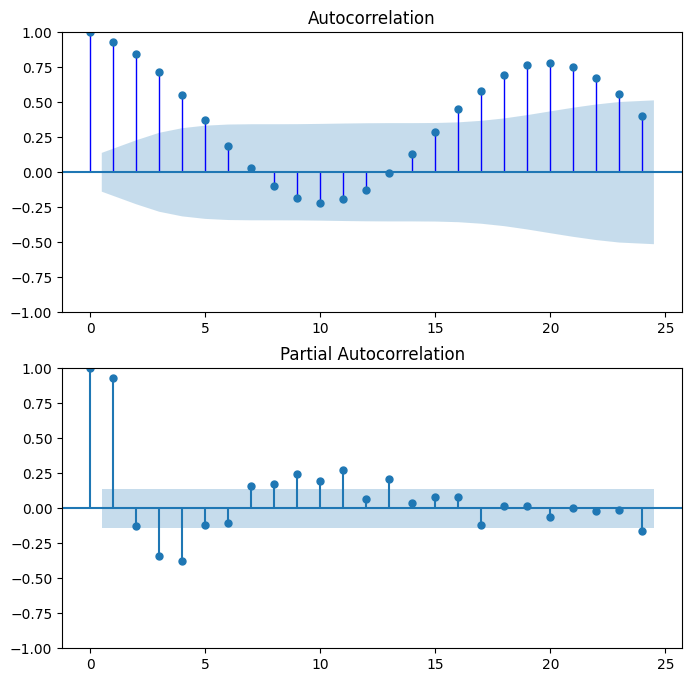

In [180]:
_, ax = plt.subplots(2, 1, figsize=(8, 8))
plot_acf(df[['decomp_sazonalidade']], alpha=.05, vlines_kwargs={'colors': 'blue', 'linewidth': 1}, ax=ax[0])
plot_pacf(df[['decomp_sazonalidade']], ax=ax[1]);

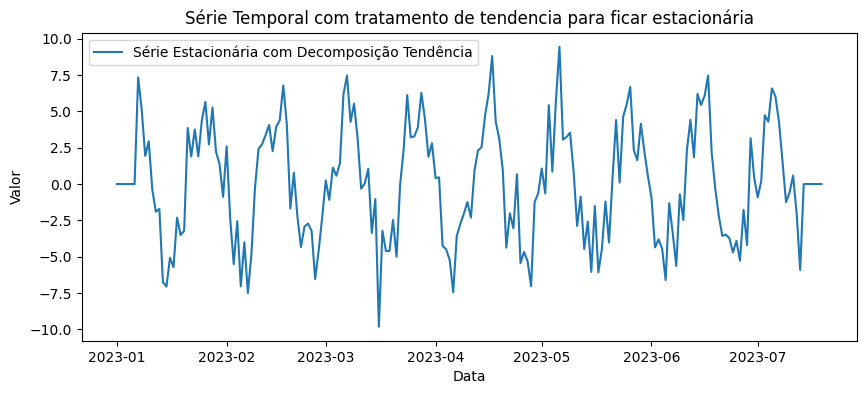

In [181]:
plt.figure(figsize=(10,4))
plt.plot(df['Data'], df['decomp_tendencia'], label='Série Estacionária com Decomposição Tendência')
plt.title('Série Temporal com tratamento de tendencia para ficar estacionária')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [182]:
stat_test(df, 'decomp_tendencia')

ADFULLER: (np.float64(-8.391919920659157), np.float64(2.3540898667290847e-13), 14, 185, {'1%': np.float64(-3.4662005731940853), '5%': np.float64(-2.8772932777920364), '10%': np.float64(-2.575167750182615)}, np.float64(788.400455910005))
KPSS: (np.float64(0.01326194188539936), np.float64(0.1), 8, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})


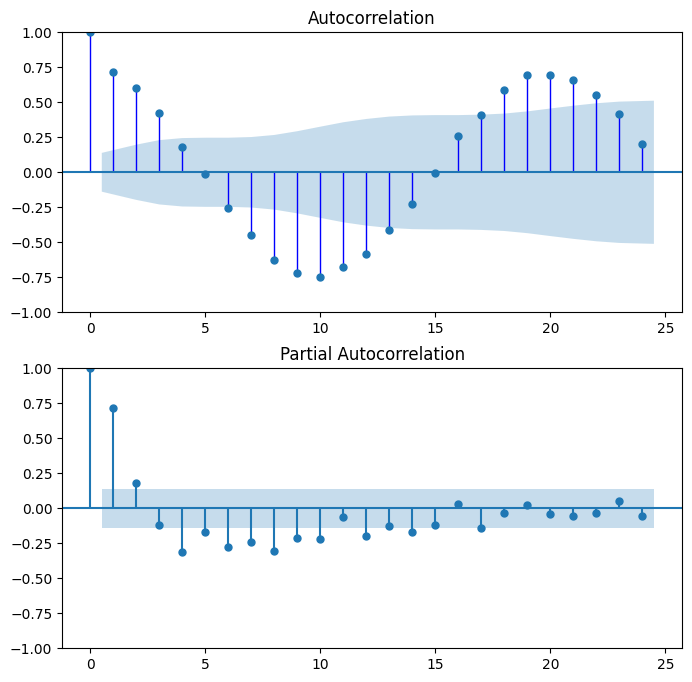

In [183]:
_, ax = plt.subplots(2, 1, figsize=(8, 8))
plot_acf(df[['decomp_tendencia']], alpha=.05, vlines_kwargs={'colors': 'blue', 'linewidth': 1}, ax=ax[0])
plot_pacf(df[['decomp_tendencia']], ax=ax[1]);

# Base para modelagem

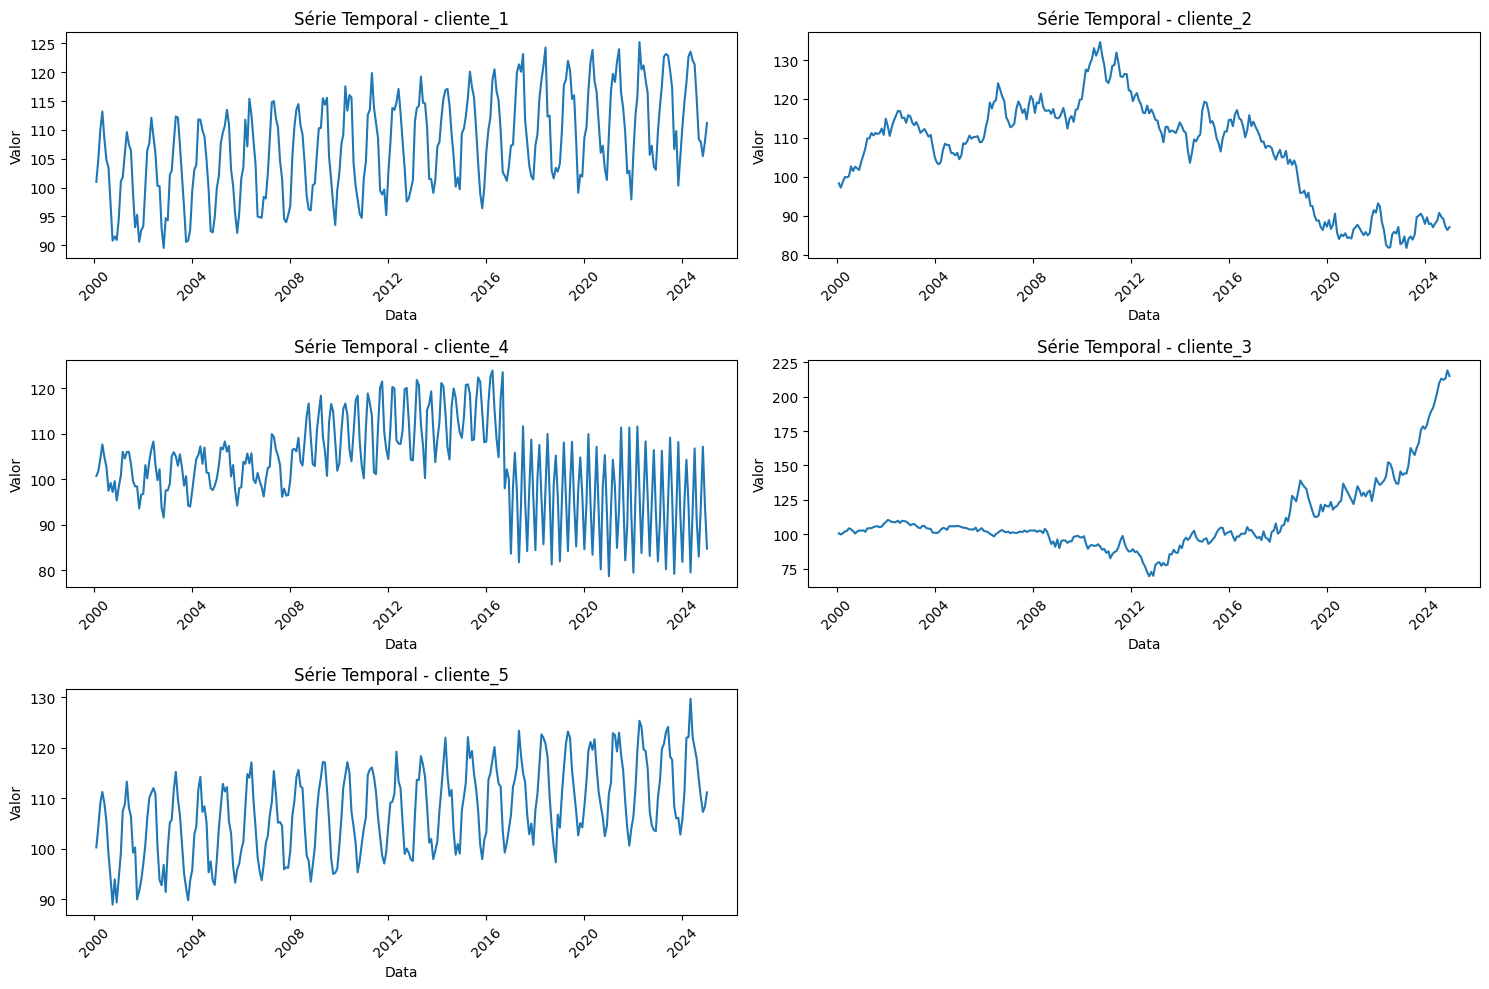

Primeiras 15 linhas dos dados:
         data cliente_id       valor
0  2000-01-31  cliente_1  100.993428
1  2000-01-31  cliente_2   98.342010
2  2000-01-31  cliente_4  100.737347
3  2000-01-31  cliente_3  100.756989
4  2000-01-31  cliente_5  100.250449
5  2000-02-29  cliente_3   99.834823
6  2000-02-29  cliente_5  104.191189
7  2000-02-29  cliente_2   97.221648
8  2000-02-29  cliente_1  104.773471
9  2000-02-29  cliente_4  101.743322
10 2000-03-31  cliente_1  110.055631
11 2000-03-31  cliente_4  104.447617
12 2000-03-31  cliente_2   98.716235
13 2000-03-31  cliente_5  109.004849
14 2000-03-31  cliente_3  100.704429

Estatísticas por cliente:
            count        mean        std        min         25%         50%  \
cliente_id                                                                    
cliente_1   300.0  107.463903   8.386586  89.534578  101.345145  107.699224   
cliente_2   300.0  107.202351  12.944375  81.737983   98.061919  110.667501   
cliente_3   300.0  110.675370  26.

In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configurações
np.random.seed(42)  # Para reproducibilidade
n_points = 300
n_clientes = 5
data_inicio = '2000-01-01'

# Criar datas mensais
datas = pd.date_range(start=data_inicio, periods=n_points, freq='M')

# Criar DataFrame
df = pd.DataFrame({'data': np.tile(datas, n_clientes)})

# Adicionar IDs dos clientes
df['cliente_id'] = np.repeat([f'cliente_{i+1}' for i in range(n_clientes)], n_points)

# Função para criar série temporal não estacionária
def criar_serie_nao_estacionaria(n, tipo='tendencia_sazonal'):
    t = np.arange(n)
    
    if tipo == 'tendencia_sazonal':
        # Componentes não estacionários
        tendencia = 0.05 * t  # Tendência linear
        sazonalidade = 10 * np.sin(2 * np.pi * t / 12)  # Sazonalidade anual
        ruido = np.random.normal(0, 2, n)  # Ruído
        return tendencia + sazonalidade + ruido + 100  # Nível base
    
    elif tipo == 'random_walk':
        # Random walk (passeio aleatório)
        return np.cumsum(np.random.normal(0, 2, n)) + 100
    
    elif tipo == 'mudanca_variancia':
        # Mudança na variância ao longo do tempo
        variancia = np.where(t < 100, 1, 
                            np.where(t < 200, 3, 5))
        return np.cumsum(np.random.normal(0, variancia, n)) + 100
    
    else:
        # Combinação de diferentes padrões
        parte1 = 0.03 * t[:100] + 5 * np.sin(2 * np.pi * t[:100] / 12)
        parte2 = 0.08 * t[100:200] + 8 * np.sin(2 * np.pi * t[100:200] / 6)
        parte3 = -0.02 * t[200:] + 12 * np.sin(2 * np.pi * t[200:] / 4)
        return np.concatenate([parte1, parte2, parte3]) + np.random.normal(0, 2, n) + 100

# Criar séries temporais para cada cliente com diferentes padrões
padroes = ['tendencia_sazonal', 'random_walk', 'mudanca_variancia', 'combinado', 'tendencia_sazonal']
valores = []

for i, cliente in enumerate([f'cliente_{j+1}' for j in range(n_clientes)]):
    serie = criar_serie_nao_estacionaria(n_points, padroes[i])
    valores.extend(serie)

df['valor'] = valores

# Ordenar por cliente e data
# df = df.sort_values(['cliente_id', 'data']).reset_index(drop=True)
df = df.sort_values(['data']).reset_index(drop=True)

# Visualizar as séries temporais
plt.figure(figsize=(15, 10))
for i, cliente in enumerate(df['cliente_id'].unique()):
    plt.subplot(3, 2, i+1)
    dados_cliente = df[df['cliente_id'] == cliente]
    plt.plot(dados_cliente['data'], dados_cliente['valor'])
    plt.title(f'Série Temporal - {cliente}')
    plt.xlabel('Data')
    plt.ylabel('Valor')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Mostrar primeiras linhas dos dados
print("Primeiras 15 linhas dos dados:")
print(df.head(15))

# Estatísticas descritivas por cliente
print("\nEstatísticas por cliente:")
print(df.groupby('cliente_id')['valor'].describe())

# Testar estacionariedade (usando diferença primeira para verificar)
print("\nVerificação de estacionariedade (primeira diferença):")
for cliente in df['cliente_id'].unique():
    dados_cliente = df[df['cliente_id'] == cliente]['valor']
    diff = dados_cliente.diff().dropna()
    print(f"{cliente}: Média da diferença = {diff.mean():.4f}")

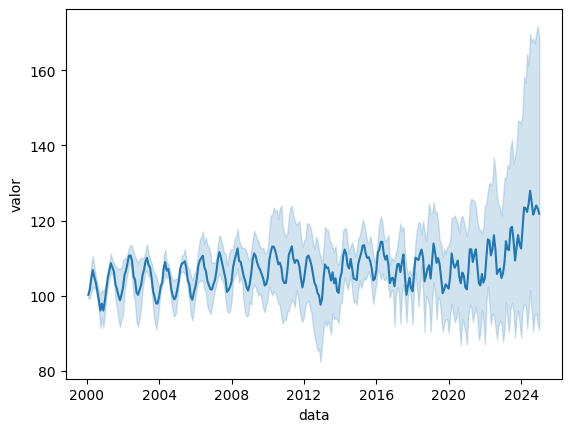

In [202]:
sns.lineplot(df, x=df['data'], y=df['valor'])
plt.show()